# Direct refinement комплексного spline-memory DPD

## Воспроизводимый отчёт по BlackBox experiment

**Статус доказательности:** результаты этого notebook относятся только к зафиксированному программному PA evaluator. Предыскажённый сигнал не подавался на физический усилитель; официальный спектральный критерий отсутствует. Выполнена заранее зарегистрированная one-shot проверка на untouched test waveform, но она также проходит через тот же PA evaluator.

Notebook не содержит исходные измерения и не переобучает модели. Он формирует проверяемый отчёт из сохранённых JSON/NPZ-артефактов, созданных скриптами `experiments/evaluate_blackbox_dpd_hypotheses.py` и `experiments/release_blackbox_direct_dpd.py`. Все числа и графики ниже читаются из этих артефактов при выполнении ячеек.

## 1. Краткий итог

Исследовательский вопрос: можно ли заметно улучшить качество каскада `DPD → PA evaluator`, не увеличивая стоимость рабочей spline-memory DPD?

Проверенная гипотеза состоит в том, что исходная архитектура уже достаточно выразительна, но ILA-калибровка оптимизирует приближённую обратную задачу. Поэтому коэффициенты исходного сплайна дополнительно уточняются по локальной чувствительности всего каскада. Итоговые значения выводятся из артефактов в следующей ячейке.

In [1]:
from __future__ import annotations

import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display


def find_repo_root() -> Path:
    'Найти корень проекта независимо от каталога запуска notebook.'
    candidates = [Path.cwd(), *Path.cwd().parents]
    marker = Path("experiments/results/blackbox_dpd_hypotheses_quick")
    for candidate in candidates:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(
        "Не найден корень DPD: запустите notebook из репозитория, содержащего "
        "experiments/results/blackbox_dpd_hypotheses_quick."
    )


def read_json(path: Path) -> dict:
    'Загрузить JSON и отклонить отсутствие ожидаемого артефакта.'
    if not path.is_file():
        raise FileNotFoundError(f"Отсутствует обязательный артефакт: {path}")
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def sha256(path: Path) -> str:
    'Вычислить SHA-256 источника отчёта.'
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def markdown_table(headers, rows):
    'Показать компактную Markdown-таблицу без зависимости от pandas.'
    def safe(value):
        return str(value).replace("|", "\\|").replace("\n", " ")
    lines = [
        "| " + " | ".join(map(safe, headers)) + " |",
        "|" + "|".join("---" for _ in headers) + "|",
    ]
    lines.extend("| " + " | ".join(map(safe, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))


REPO_ROOT = find_repo_root()
RESULTS = REPO_ROOT / "experiments/results/blackbox_dpd_hypotheses_quick"
BASELINE_RESULTS = REPO_ROOT / "experiments/results/blackbox_dpd_v1_selection"
PA_RESULTS = REPO_ROOT / "experiments/results/blackbox_pa_v2_selection"
SOURCE_SCRIPT = REPO_ROOT / "experiments/evaluate_blackbox_dpd_hypotheses.py"

artifact_paths = {
    "residual": RESULTS / "residual_analysis.json",
    "direct": RESULTS / "direct_refinement.json",
    "robustness": RESULTS / "direct_refinement_robustness.json",
    "iterative": RESULTS / "iterative_direct.json",
    "cross": RESULTS / "cross_memory.json",
    "gmp": RESULTS / "gmp_residual.json",
    "fir": RESULTS / "short_fir.json",
    "knots": RESULTS / "knot_strategies.json",
    "alternative": RESULTS / "alternative_evaluator.json",
    "pareto": RESULTS / "pareto_summary.json",
    "fixed_point": RESULTS / "fixed_point.json",
    "sealed_test": REPO_ROOT / "experiments/results/blackbox_direct_dpd_test_release/test_evaluation.json",
    "preregistration": REPO_ROOT / "experiments/configs/blackbox_direct_dpd_test_preregistration.json",
    "selection_manifest": BASELINE_RESULTS / "selection_manifest.json",
}
artifacts = {name: read_json(path) for name, path in artifact_paths.items()}

direct = artifacts["direct"]
iterative = artifacts["iterative"]
pareto = artifacts["pareto"]
selection_manifest = artifacts["selection_manifest"]

plt.rcParams.update({
    "figure.figsize": (10.5, 5.4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

generated_at = datetime.now(timezone.utc).isoformat(timespec="seconds")
print(f"Корень проекта: {REPO_ROOT}")
print(f"Отчёт сформирован: {generated_at}")
print(f"SHA-256 экспериментального скрипта: {sha256(SOURCE_SCRIPT)}")
print(f"Загружено обязательных JSON-артефактов: {len(artifacts)}")

Корень проекта: /home/jordea/Рабочий стол/Projects/DPD
Отчёт сформирован: 2026-08-11T16:59:47+00:00
SHA-256 экспериментального скрипта: 2215aaf7dc4af304c81bb79a23cd6b13bcf1498f0982c362e06e70c85ac26252
Загружено обязательных JSON-артефактов: 14


In [2]:
no_dpd_nmse = direct["baseline_validation"]["no_dpd_nmse_db"]
ila_nmse = direct["baseline_validation"]["nmse_db"]
one_update_nmse = direct["refined_validation"]["nmse_db"]
iterative_nmse = iterative["final_validation"]["nmse_db"]
gain_vs_ila = ila_nmse - iterative_nmse
gain_vs_no_dpd = no_dpd_nmse - iterative_nmse
operations = iterative["operation_count"]
fixed_point = artifacts["fixed_point"]
sealed_test = artifacts["sealed_test"]

display(Markdown(f'''
> **Результат на validation frozen PA evaluator.** Итерационное direct refinement улучшило NMSE с **{ila_nmse:.3f} dB** до **{iterative_nmse:.3f} dB**: выигрыш **{gain_vs_ila:.3f} dB** относительно ILA и **{gain_vs_no_dpd:.3f} dB** относительно режима без DPD. На заранее зарегистрированном untouched test waveform получено **{sealed_test['metrics']['iterative_direct_spline']['pooled_complex_nmse_db']:.3f} dB**, то есть **{sealed_test['derived']['gain_over_ila_db']:.3f} dB** относительно ILA. Рабочая модель не изменилась: **{operations['real_multiplications']} MUL** и **{operations['real_additions']} ADD** на комплексный отсчёт. 12-bit loss относительно float на validation составил **{fixed_point['formats'][-1]['cascade_degradation_vs_float_db']:.4f} dB**.

Это сильный **surrogate-only** результат, а не доказательство физической линеаризации PA.
'''))


> **Результат на validation frozen PA evaluator.** Итерационное direct refinement улучшило NMSE с **-17.192 dB** до **-21.588 dB**: выигрыш **4.395 dB** относительно ILA и **5.577 dB** относительно режима без DPD. На заранее зарегистрированном untouched test waveform получено **-21.545 dB**, то есть **4.337 dB** относительно ILA. Рабочая модель не изменилась: **27 MUL** и **28 ADD** на комплексный отсчёт. 12-bit loss относительно float на validation составил **0.0141 dB**.

Это сильный **surrogate-only** результат, а не доказательство физической линеаризации PA.


## 2. Постановка и исходная архитектура

Пусть $x[n]$ — желаемый комплексный I/Q-сигнал, $D_{\mathbf c}$ — DPD с коэффициентами $\mathbf c$, а $\widehat P$ — замороженная модель усилителя. Правильная проверка выполняется в направлении

$$
x_{\mathrm{desired}} \rightarrow D_{\mathbf c} \rightarrow \widehat P \rightarrow \widehat y,
\qquad \widehat y \approx g x_{\mathrm{desired}}.
$$

Исходная фазово-эквивариантная spline-memory модель:

$$
z[n]=\sum_{m=0}^{2}x[n-m]C_m\!\left(|x[n-m]|\right),
$$

где $C_m(r)$ — комплексный кусочно-линейный сплайн. В каждой ветви на одном отсчёте активны только два соседних узла. Поскольку модуль не зависит от общей фазы,

$$
D(xe^{j\varphi})=D(x)e^{j\varphi}.
$$

Direct refinement не добавляет ветви и не меняет эту формулу: меняется только банк комплексных коэффициентов.

In [3]:
baseline_npz_path = BASELINE_RESULTS / "selected_dpd.npz"
iterative_npz_path = RESULTS / "iterative_direct_model.npz"
baseline_model = np.load(baseline_npz_path)
iterative_model = np.load(iterative_npz_path)

for key in ("knots", "signal_delays", "envelope_delays", "coefficients"):
    assert key in baseline_model and key in iterative_model, f"Нет поля {key}"
assert np.array_equal(baseline_model["knots"], iterative_model["knots"])
assert np.array_equal(baseline_model["signal_delays"], iterative_model["signal_delays"])
assert np.array_equal(baseline_model["envelope_delays"], iterative_model["envelope_delays"])
assert baseline_model["coefficients"].shape == iterative_model["coefficients"].shape

branch_count, knot_count = iterative_model["coefficients"].shape
complex_coefficient_count = branch_count * knot_count
print(f"Ветвей: {branch_count}; узлов на ветвь: {knot_count}")
print(f"Комплексных коэффициентов: {complex_coefficient_count}")
print("Задержки сигнала:", iterative_model["signal_delays"].tolist())
print("Задержки огибающей:", iterative_model["envelope_delays"].tolist())
print("Топология и узлы исходной и refined-моделей совпадают: PASS")

Ветвей: 3; узлов на ветвь: 24
Комплексных коэффициентов: 72
Задержки сигнала: [0, 1, 2]
Задержки огибающей: [0, 1, 2]
Топология и узлы исходной и refined-моделей совпадают: PASS


## 3. Почему ILA можно улучшить

### ILA-калибровка

Исходный банк коэффициентов получен как postdistorter:

$$
\min_{\mathbf c}\left\|D_{\mathbf c}(y/g)-x\right\|_2^2.
$$

После обучения эти коэффициенты переносятся в predistorter. Метод быстрый и даёт полезную начальную точку, но его функция потерь не совпадает с конечной задачей.

### Direct objective

Для каскада требуется минимизировать

$$
\mathcal L$\mathbf c$=
\left\|\widehat P\!\left(D_{\mathbf c}(x)\right)-gx\right\|_2^2.
$$

Direct refinement начинает с ILA-банка и уточняет те же коэффициенты непосредственно по ошибке каскада. Измеренный $y_{val}$ не подаётся на вход DPD при deployment-like проверке.

## 4. Локальная линеаризация и ridge update

В окрестности текущего банка $\boldsymbol\theta$, где отдельно записаны вещественные и мнимые части комплексных коэффициентов,

$$
\widehat y(\boldsymbol\theta+\Delta\boldsymbol\theta)
\approx
\widehat y$\boldsymbol\theta$+J\Delta\boldsymbol\theta.
$$

Столбцы $J$ оцениваются конечными разностями через замороженный PA evaluator:

$$
J_k \approx
\frac{
\widehat P(D_{\boldsymbol\theta+\varepsilon e_k}(x))-
\widehat P(D_{\boldsymbol\theta}(x))
}{\varepsilon}.
$$

Поправка находится из регуляризованной задачи

$$
\Delta\boldsymbol\theta=
\arg\min_{\Delta}
\|J\Delta-e\|_2^2+\lambda\|\Delta\|_2^2,
\quad e=gx-\widehat y,
$$

а банк обновляется ограниченным шагом

$$
\boldsymbol\theta_{new}=\boldsymbol\theta_{old}+\alpha\Delta\boldsymbol\theta.
$$

Эта процедура усложняет только калибровку. В sample-rate тракте остаётся исходная spline-memory формула.

In [4]:
selected_update = direct["selected_on_disjoint_train_advisor"]
markdown_table(
    ["Параметр", "Значение", "Источник/роль"],
    [
        ["Размер Jacobian", str(tuple(direct["jacobian_shape"])), "direct_refinement.json"],
        ["Конечная разность ε", f"{direct['finite_difference_epsilon']:.1e}", "фиксированная настройка"],
        ["Выбранный ridge", f"{selected_update['ridge']:.1e}", "отдельный train-advisor"],
        ["Шаг α", f"{selected_update['step']:.3f}", "отдельный train-advisor"],
        ["Относительная норма Δc", f"{direct['coefficient_change_relative_norm']:.4f}", "диагностика"],
        ["Validation использовалась для выбора", str(direct["calibration_split"]["validation_used_for_coefficient_or_step_selection"]), "должно быть False"],
    ],
)

| Параметр | Значение | Источник/роль |
|---|---|---|
| Размер Jacobian | (8170, 144) | direct_refinement.json |
| Конечная разность ε | 1.0e-04 | фиксированная настройка |
| Выбранный ridge | 1.0e-08 | отдельный train-advisor |
| Шаг α | 1.000 | отдельный train-advisor |
| Относительная норма Δc | 0.2698 | диагностика |
| Validation использовалась для выбора | False | должно быть False |

## 5. Дисциплина разделения данных

Train и validation — последовательные непересекающиеся участки **одного** BlackBox capture. Это предотвращает прямую утечку отсчётов, но не является независимой проверкой на другом физическом режиме.

- alignment, комплексный gain и normalization определены только по train;
- Jacobian строится на train-подблоке;
- ridge и шаг выбираются на другом train-advisor блоке;
- validation не участвует в вычислении direct update или остановке итераций;
- sealed/test данные текущему селектору недоступны.

In [5]:
provenance = selection_manifest["data_provenance"]
split_contract = provenance["split_contract"]
calibration_split = direct["calibration_split"]

assert provenance["sealed_or_test_data_available_to_selector"] is False
assert calibration_split["validation_used_for_coefficient_or_step_selection"] is False
assert iterative["validation_used_for_update_or_stopping"] is False

markdown_table(
    ["Область", "Начало", "Конец", "Количество", "Назначение"],
    [
        ["Train capture", split_contract["train"]["start"], split_contract["train"]["stop"], split_contract["train"]["count"], "исходная калибровка"],
        ["Jacobian block", *calibration_split["jacobian"], calibration_split["jacobian"][1] - calibration_split["jacobian"][0], "оценка чувствительности"],
        ["Train-advisor", *calibration_split["advisor"], calibration_split["advisor"][1] - calibration_split["advisor"][0], "выбор ridge и шага"],
        ["Validation capture", split_contract["validation"]["start"], split_contract["validation"]["stop"], split_contract["validation"]["count"], "итоговая surrogate-оценка"],
    ],
)
print("Hash исходного capture подтверждён:", provenance["expected_actual_source_hash_match"])
print("Hash selection view подтверждён:", provenance["expected_actual_selection_view_hash_match"])

| Область | Начало | Конец | Количество | Назначение |
|---|---|---|---|---|
| Train capture | 5000 | 97000 | 92000 | исходная калибровка |
| Jacobian block | 16384 | 20480 | 4096 | оценка чувствительности |
| Train-advisor | 32768 | 40960 | 8192 | выбор ridge и шага |
| Validation capture | 97000 | 120000 | 23000 | итоговая surrogate-оценка |

Hash исходного capture подтверждён: True
Hash selection view подтверждён: True


## 6. Основной validation-результат

Метрика — pooled complex NMSE:

$$
\operatorname{NMSE}_{dB}=10\log_{10}
\frac{\sum_n|\widehat y[n]-gx[n]|^2}{\sum_n|gx[n]|^2}.
$$

Чем значение ниже, тем меньше нормированная мощность ошибки. На графике показан правильный deployment-like путь через один и тот же frozen PA evaluator.

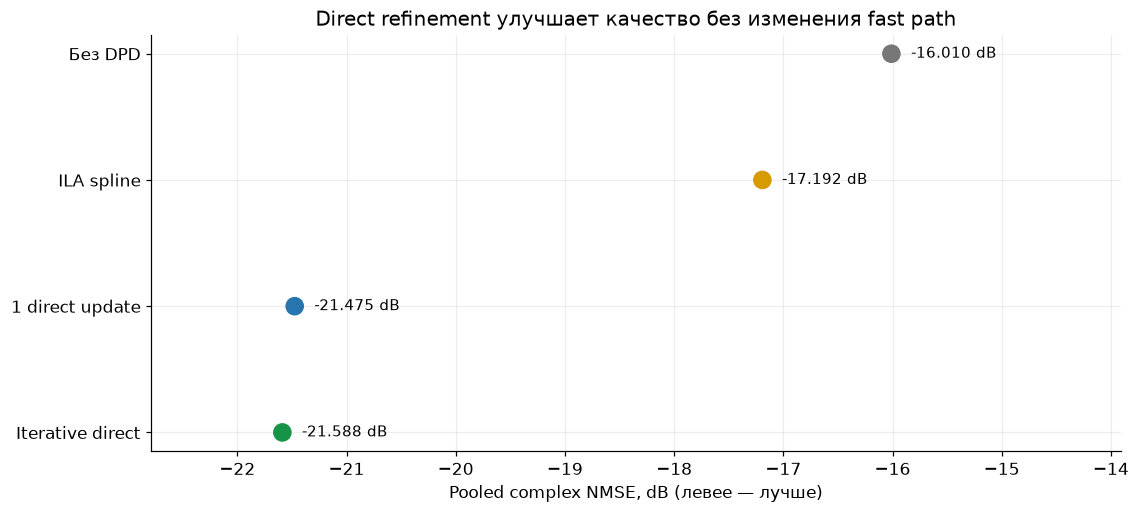

| Режим | NMSE, dB | Улучшение к no DPD, dB | MUL | ADD |
|---|---|---|---|---|
| Без DPD | -16.010351 | 0.000000 | 0 | 0 |
| ILA spline-memory | -17.192240 | 1.181890 | 27 | 28 |
| Один direct update | -21.474655 | 5.464304 | 27 | 28 |
| Iterative direct | -21.587580 | 5.577229 | 27 | 28 |

In [6]:
nmse_labels = ["Без DPD", "ILA spline", "1 direct update", "Iterative direct"]
nmse_values = [no_dpd_nmse, ila_nmse, one_update_nmse, iterative_nmse]
nmse_colors = ["#777777", "#d79a00", "#2774ae", "#159447"]

fig, ax = plt.subplots(figsize=(10.5, 4.8))
y = np.arange(len(nmse_labels))
ax.scatter(nmse_values, y, s=125, c=nmse_colors, zorder=3)
for value, yi in zip(nmse_values, y):
    ax.text(value + 0.18, yi, f"{value:.3f} dB", va="center", fontsize=10)
ax.set_yticks(y, nmse_labels)
ax.set_xlabel("Pooled complex NMSE, dB (левее — лучше)")
ax.set_title("Direct refinement улучшает качество без изменения fast path")
ax.set_xlim(min(nmse_values) - 1.2, max(nmse_values) + 2.1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

markdown_table(
    ["Режим", "NMSE, dB", "Улучшение к no DPD, dB", "MUL", "ADD"],
    [
        ["Без DPD", f"{no_dpd_nmse:.6f}", "0.000000", 0, 0],
        ["ILA spline-memory", f"{ila_nmse:.6f}", f"{no_dpd_nmse - ila_nmse:.6f}", operations["real_multiplications"], operations["real_additions"]],
        ["Один direct update", f"{one_update_nmse:.6f}", f"{no_dpd_nmse - one_update_nmse:.6f}", operations["real_multiplications"], operations["real_additions"]],
        ["Iterative direct", f"{iterative_nmse:.6f}", f"{no_dpd_nmse - iterative_nmse:.6f}", operations["real_multiplications"], operations["real_additions"]],
    ],
)

### 6.1. Наглядная проверка AM/AM, AM/PM и спектра

Эти диаграммы показывают тот же эффект, что и иллюстрации на слайде научного руководителя, но для нашей комплексной модели. Компоненты I и Q здесь **не обучаются раздельно**: они образуют один комплексный сигнал, поэтому нелинейность удобнее разложить на изменение амплитуды и фазы.

Для каждого validation-отсчёта используются

$$
A_{in}[n]=|x[n]|,
\qquad
A_{out}[n]=|\widehat y[n]|,
$$

$$
\Delta\varphi[n]=
\arg\!\left(\widehat y[n]\,(g x[n])^*\right).
$$

- **AM/AM** показывает, как выходная амплитуда зависит от желаемой входной амплитуды. При идеальной линеаризации точки лежат на чёрной прямой $|gx|$.
- **AM/PM** показывает остаточную фазовую ошибку. Около нулевой амплитуды фаза плохо определена, поэтому для этой панели исключены только отсчёты ниже 2% максимальной амплитуды.
- **PSD** показывает расширение спектра. Здесь ось частоты нормирована в cycles/sample: подтверждённая частота дискретизации и официальные границы каналов для BlackBox capture неизвестны, поэтому график является визуальной спектральной диагностикой, а не официальным ACLR.

Все три режима проверяются одним deployment-like путём $x_{val}\rightarrow DPD\rightarrow\widehat P$. Измеренный $y_{val}$ не используется как вход DPD.

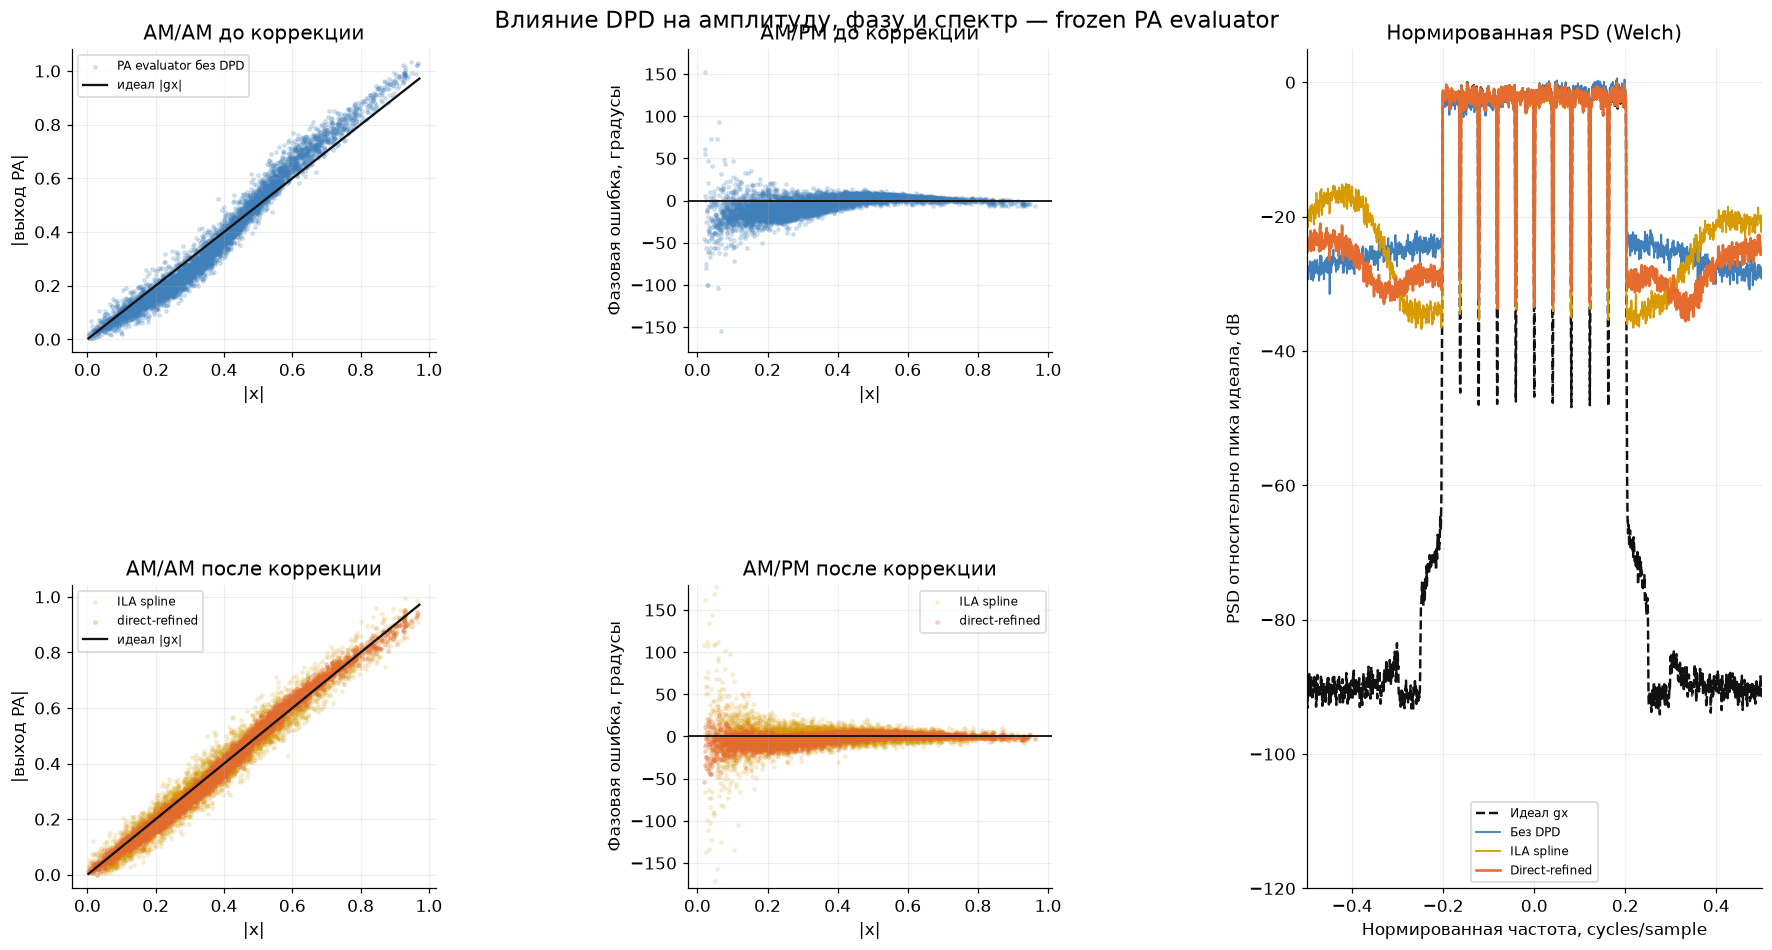

Validation source: frozen BlackBox selection view
Welch: Hann, nperseg=2048, overlap=75%, normalized frequency
Measured validation y used as DPD input: False
ILA NMSE: -17.192240 dB
Direct-refined NMSE: -21.587580 dB


In [7]:
import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from baseline.spline_memory_dpd import SparseSplineMemoryDPD
from experiments.evaluate_blackbox_dpd_hypotheses import (
    COMMON_WARMUP,
    evaluate_model,
    load_context,
)


def welch_power(signal: np.ndarray, nperseg: int = 2048, overlap: float = 0.75):
    """Return a Hann-windowed Welch power spectrum on a normalized frequency axis."""
    values = np.asarray(signal, dtype=np.complex128)
    nperseg = min(int(nperseg), values.size)
    step = max(1, int(round(nperseg * (1.0 - overlap))))
    window = np.hanning(nperseg)
    window_energy = float(np.sum(window**2))
    starts = range(0, values.size - nperseg + 1, step)
    spectra = [
        np.abs(np.fft.fft(window * values[start:start + nperseg])) ** 2
        / window_energy
        for start in starts
    ]
    if not spectra:
        raise ValueError("Недостаточно отсчётов для Welch PSD")
    power = np.mean(spectra, axis=0)
    frequency = np.fft.fftfreq(nperseg, d=1.0)
    return np.fft.fftshift(frequency), np.fft.fftshift(power)


def phase_residual_deg(output: np.ndarray, reference: np.ndarray) -> np.ndarray:
    """Return wrapped phase error relative to the complex ideal reference."""
    return np.rad2deg(np.angle(output * np.conj(reference)))


# Recreate the frozen validation cascade from the immutable project bundles.
visual_context = load_context()
visual_ila = evaluate_model(
    visual_context,
    visual_context.baseline,
    visual_context.validation_x,
)
visual_direct_model = SparseSplineMemoryDPD.load(iterative_npz_path)
visual_direct = evaluate_model(
    visual_context,
    visual_direct_model,
    visual_context.validation_x,
)

assert np.isclose(visual_ila["nmse_db"], ila_nmse, atol=1e-12)
assert np.isclose(visual_direct["nmse_db"], iterative_nmse, atol=1e-12)

scored = np.arange(COMMON_WARMUP, visual_context.validation_x.size)
# Deterministic thinning keeps individual-sample dispersion visible without hiding the curves.
scatter_indices = scored[::4]
desired_amplitude = np.abs(visual_context.validation_x)
ideal_output = visual_direct["ideal"]
ideal_amplitude = np.abs(ideal_output)
phase_mask = ideal_amplitude > 0.02 * float(np.max(ideal_amplitude))
phase_indices = scored[phase_mask[scored]][::4]

colors = {
    "no_dpd": "#3f7fba",
    "ila": "#d79a00",
    "direct": "#e56b2f",
    "ideal": "#111111",
}

fig = plt.figure(figsize=(16.0, 8.4), layout="constrained")
grid = fig.add_gridspec(2, 3, width_ratios=(1.0, 1.0, 1.25), wspace=0.28, hspace=0.34)
ax_amam_before = fig.add_subplot(grid[0, 0])
ax_ampm_before = fig.add_subplot(grid[0, 1])
ax_amam_after = fig.add_subplot(grid[1, 0])
ax_ampm_after = fig.add_subplot(grid[1, 1])
ax_psd = fig.add_subplot(grid[:, 2])

# Before correction.
ax_amam_before.scatter(
    desired_amplitude[scatter_indices],
    np.abs(visual_direct["no_dpd_output"])[scatter_indices],
    s=5, alpha=0.18, color=colors["no_dpd"], label="PA evaluator без DPD",
)
order = np.argsort(desired_amplitude[scored])
ax_amam_before.plot(
    desired_amplitude[scored][order], ideal_amplitude[scored][order],
    color=colors["ideal"], lw=1.5, label="идеал |gx|",
)
ax_amam_before.set(title="AM/AM до коррекции", xlabel="|x|", ylabel="|выход PA|")
ax_amam_before.legend(fontsize=8)

ax_ampm_before.scatter(
    desired_amplitude[phase_indices],
    phase_residual_deg(visual_direct["no_dpd_output"], ideal_output)[phase_indices],
    s=5, alpha=0.18, color=colors["no_dpd"],
)
ax_ampm_before.axhline(0.0, color=colors["ideal"], lw=1.2)
ax_ampm_before.set(
    title="AM/PM до коррекции", xlabel="|x|",
    ylabel="Фазовая ошибка, градусы", ylim=(-180, 180),
)

# After correction: ILA is the initialization, direct refinement is the final bank.
ax_amam_after.scatter(
    desired_amplitude[scatter_indices], np.abs(visual_ila["output"])[scatter_indices],
    s=5, alpha=0.12, color=colors["ila"], label="ILA spline",
)
ax_amam_after.scatter(
    desired_amplitude[scatter_indices], np.abs(visual_direct["output"])[scatter_indices],
    s=5, alpha=0.24, color=colors["direct"], label="direct-refined",
)
ax_amam_after.plot(
    desired_amplitude[scored][order], ideal_amplitude[scored][order],
    color=colors["ideal"], lw=1.5, label="идеал |gx|",
)
ax_amam_after.set(title="AM/AM после коррекции", xlabel="|x|", ylabel="|выход PA|")
ax_amam_after.legend(fontsize=8)

ax_ampm_after.scatter(
    desired_amplitude[phase_indices],
    phase_residual_deg(visual_ila["output"], ideal_output)[phase_indices],
    s=5, alpha=0.12, color=colors["ila"], label="ILA spline",
)
ax_ampm_after.scatter(
    desired_amplitude[phase_indices],
    phase_residual_deg(visual_direct["output"], ideal_output)[phase_indices],
    s=5, alpha=0.24, color=colors["direct"], label="direct-refined",
)
ax_ampm_after.axhline(0.0, color=colors["ideal"], lw=1.2)
ax_ampm_after.set(
    title="AM/PM после коррекции", xlabel="|x|",
    ylabel="Фазовая ошибка, градусы", ylim=(-180, 180),
)
ax_ampm_after.legend(fontsize=8)

# PSD: every curve uses the same Welch estimator and the same ideal-spectrum reference.
spectral_signals = {
    "Идеал gx": (ideal_output[COMMON_WARMUP:], colors["ideal"], "--", 1.6),
    "Без DPD": (visual_direct["no_dpd_output"][COMMON_WARMUP:], colors["no_dpd"], "-", 1.2),
    "ILA spline": (visual_ila["output"][COMMON_WARMUP:], colors["ila"], "-", 1.2),
    "Direct-refined": (visual_direct["output"][COMMON_WARMUP:], colors["direct"], "-", 1.7),
}
spectra = {}
for name, (signal, color, linestyle, linewidth) in spectral_signals.items():
    frequency, power = welch_power(signal, nperseg=2048, overlap=0.75)
    spectra[name] = power
ideal_peak = float(np.max(spectra["Идеал gx"]))
for name, (_, color, linestyle, linewidth) in spectral_signals.items():
    power_db = 10.0 * np.log10(np.maximum(spectra[name], ideal_peak * 1e-14) / ideal_peak)
    ax_psd.plot(frequency, power_db, color=color, linestyle=linestyle, lw=linewidth, label=name)
ax_psd.set(
    title="Нормированная PSD (Welch)",
    xlabel="Нормированная частота, cycles/sample",
    ylabel="PSD относительно пика идеала, dB",
    xlim=(-0.5, 0.5), ylim=(-120, 5),
)
ax_psd.legend(fontsize=8, loc="lower center")

fig.suptitle(
    "Влияние DPD на амплитуду, фазу и спектр — frozen PA evaluator",
    fontsize=15, y=1.01,
)
plt.show()

print("Validation source: frozen BlackBox selection view")
print("Welch: Hann, nperseg=2048, overlap=75%, normalized frequency")
print("Measured validation y used as DPD input: False")
print(f"ILA NMSE: {visual_ila['nmse_db']:.6f} dB")
print(f"Direct-refined NMSE: {visual_direct['nmse_db']:.6f} dB")

## 7. Сходимость калибровки

Первая direct-поправка даёт основную часть выигрыша. Три последующие ограниченные итерации дают малое уточнение. Показанные validation-точки являются диагностикой после заранее ограниченного числа итераций; они не использовались для остановки алгоритма.

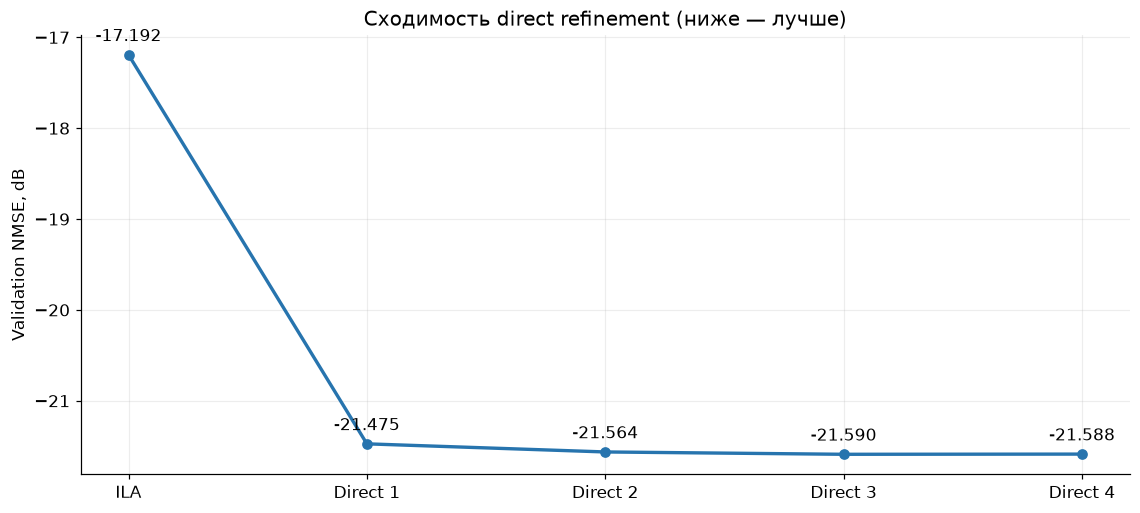

Выигрыш первого direct update относительно ILA: 4.282414 dB
Дополнительный выигрыш последующих итераций: 0.112925 dB
Разность двух порядков train-подблоков: 0.000800 dB


In [8]:
selected_schedule = iterative["schedules"][iterative["selected_schedule"]]
update_diagnostics = [
    update["validation_diagnostic_not_used_for_stopping"]["nmse_db"]
    for update in selected_schedule["updates"]
]
convergence_labels = ["ILA", "Direct 1", "Direct 2", "Direct 3", "Direct 4"]
convergence_values = [ila_nmse, one_update_nmse, *update_diagnostics]

fig, ax = plt.subplots(figsize=(10.5, 4.8))
steps = np.arange(len(convergence_values))
ax.plot(steps, convergence_values, marker="o", lw=2.2, color="#2774ae")
for step, value in zip(steps, convergence_values):
    ax.annotate(f"{value:.3f}", (step, value), xytext=(0, 9), textcoords="offset points", ha="center")
ax.set_xticks(steps, convergence_labels)
ax.set_ylabel("Validation NMSE, dB")
ax.set_title("Сходимость direct refinement (ниже — лучше)")
plt.tight_layout()
plt.show()

print(f"Выигрыш первого direct update относительно ILA: {ila_nmse - one_update_nmse:.6f} dB")
print(f"Дополнительный выигрыш последующих итераций: {iterative['validation_gain_over_one_update_db']:.6f} dB")
print(f"Разность двух порядков train-подблоков: {iterative['schedule_final_nmse_difference_db']:.6f} dB")

## 8. Устойчивость по временным сегментам

Pooled-метрика может скрыть локальные ухудшения. Поэтому validation capture разделён на восемь последовательных сегментов. Для каждого показано улучшение NMSE относительно режима без DPD.

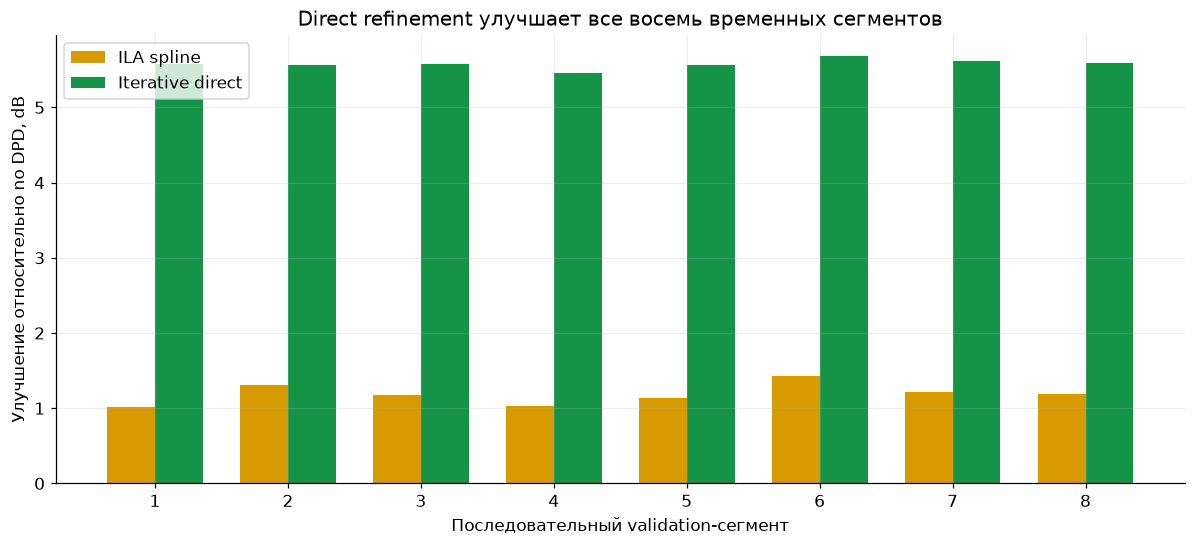

Минимальное улучшение iterative direct: 5.4544 dB
Максимальное улучшение iterative direct: 5.6804 dB
Сегментов, где iterative direct лучше ILA: 8 из 8


In [9]:
ila_segments = np.asarray(direct["baseline_validation"]["segment_improvements_db"])
iterative_segments = np.asarray(iterative["final_validation"]["segment_improvements_db"])
assert ila_segments.shape == iterative_segments.shape == (8,)
assert np.all(iterative_segments > ila_segments)

segments = np.arange(1, len(ila_segments) + 1)
width = 0.36
fig, ax = plt.subplots(figsize=(11, 5.1))
ax.bar(segments - width / 2, ila_segments, width, label="ILA spline", color="#d79a00")
ax.bar(segments + width / 2, iterative_segments, width, label="Iterative direct", color="#159447")
ax.set_xticks(segments)
ax.set_xlabel("Последовательный validation-сегмент")
ax.set_ylabel("Улучшение относительно no DPD, dB")
ax.set_title("Direct refinement улучшает все восемь временных сегментов")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Минимальное улучшение iterative direct: {iterative_segments.min():.4f} dB")
print(f"Максимальное улучшение iterative direct: {iterative_segments.max():.4f} dB")
print("Сегментов, где iterative direct лучше ILA:", int(np.sum(iterative_segments > ila_segments)), "из", len(segments))

## 9. Как изменились коэффициенты

Ниже показана величина $|c_{refined}-c_{ILA}|$ для каждого spline-узла. Это подтверждает, что архитектура не изменилась: обновлён только существующий банк коэффициентов. График не следует интерпретировать как отдельную AM/AM-характеристику всего DPD, поскольку модель содержит память и сумму трёх ветвей.

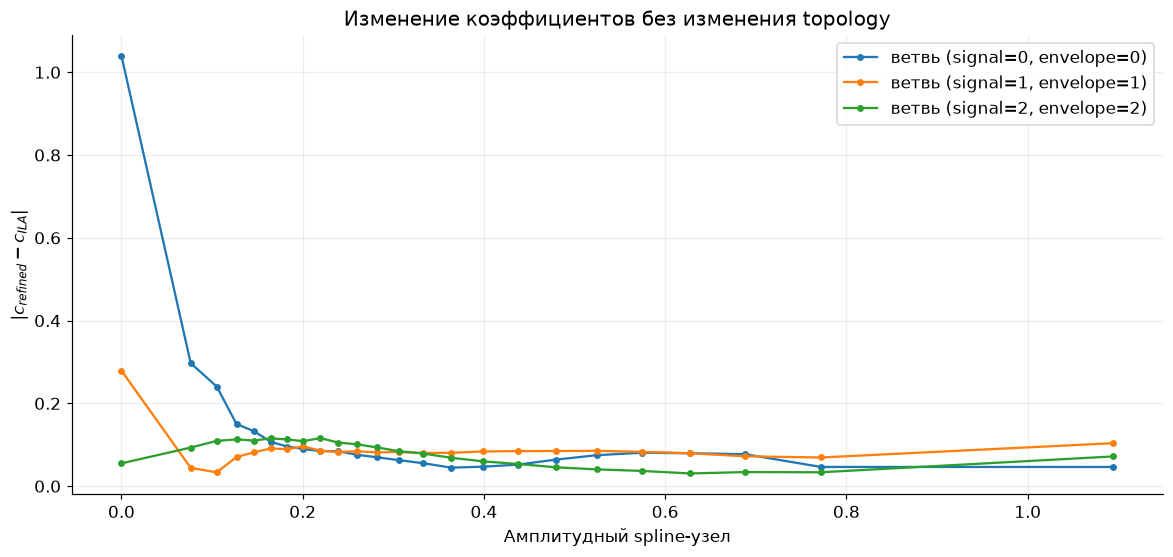

Относительная Frobenius-норма изменения коэффициентов: 0.292415
Maximum drive: ILA=0.923165, iterative=0.920485
PAPR: ILA=7.203193 dB, iterative=7.133720 dB


In [10]:
knots = iterative_model["knots"]
baseline_coefficients = baseline_model["coefficients"]
iterative_coefficients = iterative_model["coefficients"]
coefficient_delta = iterative_coefficients - baseline_coefficients
relative_delta_norm = np.linalg.norm(coefficient_delta) / np.linalg.norm(baseline_coefficients)

fig, ax = plt.subplots(figsize=(10.8, 5.2))
for branch_index, (signal_delay, envelope_delay) in enumerate(zip(
    iterative_model["signal_delays"], iterative_model["envelope_delays"]
)):
    ax.plot(
        knots,
        np.abs(coefficient_delta[branch_index]),
        marker="o",
        ms=3.5,
        label=f"ветвь (signal={signal_delay}, envelope={envelope_delay})",
    )
ax.set_xlabel("Амплитудный spline-узел")
ax.set_ylabel(r"$|c_{refined}-c_{ILA}|$")
ax.set_title("Изменение коэффициентов без изменения topology")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Относительная Frobenius-норма изменения коэффициентов: {relative_delta_norm:.6f}")
print(f"Maximum drive: ILA={direct['baseline_validation']['drive_summary']['peak']:.6f}, "
      f"iterative={iterative['final_validation']['drive_summary']['peak']:.6f}")
print(f"PAPR: ILA={direct['baseline_validation']['drive_summary']['papr_db']:.6f} dB, "
      f"iterative={iterative['final_validation']['drive_summary']['papr_db']:.6f} dB")

## 10. Последовательная проверка альтернативных гипотез

После residual analysis проверялись минимальные структурные расширения. Их нельзя оценивать только по числу параметров: каждое добавляет операции или память в sample-rate тракте.

- дополнительная cross-memory spline branch;
- одна sparse GMP residual branch;
- короткий комплексный FIR после spline;
- другое размещение 24 spline-узлов;
- несколько bounded direct updates без изменения fast path.

Внутренний gate для принятия расширения — не менее 0.5 dB при отсутствии ухудшений по дополнительным ограничениям. Это инженерный критерий проекта, а не внешнее требование.

In [11]:
cross = artifacts["cross"]
gmp = artifacts["gmp"]
fir = artifacts["fir"]
knots_result = artifacts["knots"]

ablation_rows = [
    ["ILA baseline", ila_nmse, operations["real_multiplications"], operations["real_additions"], "исходная точка"],
    ["Iterative direct", iterative_nmse, operations["real_multiplications"], operations["real_additions"], "рекомендован"],
    ["+ cross-memory spline", cross["selected"]["validation"]["nmse_db"], cross["selected"]["operation_count"]["real_multiplications"], cross["selected"]["operation_count"]["real_additions"], "отклонён: хуже ILA"],
    ["1 direct + GMP residual", gmp["residual_validation"]["nmse_db"], operations["real_multiplications"] + gmp["incremental_operation_count"]["real_multiplications"], operations["real_additions"] + gmp["incremental_operation_count"]["real_additions"], "доминируется iterative direct"],
    ["1 direct + short FIR", fir["fir_validation"]["nmse_db"], operations["real_multiplications"] + fir["incremental_operation_count"]["real_multiplications"], operations["real_additions"] + fir["incremental_operation_count"]["real_additions"], "малый выигрыш за большую цену"],
    ["Compression-aware knots", knots_result["selected"]["direct_validation"]["nmse_db"], knots_result["selected"]["operation_count"]["real_multiplications"], knots_result["selected"]["operation_count"]["real_additions"], "хуже iterative quantile"],
]

markdown_table(
    ["Конфигурация", "Validation NMSE, dB", "MUL", "ADD", "Вывод"],
    [[name, f"{nmse:.6f}", mul, add, status] for name, nmse, mul, add, status in ablation_rows],
)

print(f"Cross-memory gain относительно ILA: {cross['gain_over_baseline_dpd_db']:.6f} dB")
print(f"GMP residual gain относительно одного direct update: {gmp['validation_gain_over_direct_refined_db']:.6f} dB")
print(f"Short FIR gain относительно iterative direct: {pareto['fir_gain_over_iterative_direct_db']:.6f} dB")
print(f"Лучшее изменение knots относительно iterative quantile: {knots_result['gain_over_iterative_quantile_db']:.6f} dB")

| Конфигурация | Validation NMSE, dB | MUL | ADD | Вывод |
|---|---|---|---|---|
| ILA baseline | -17.192240 | 27 | 28 | исходная точка |
| Iterative direct | -21.587580 | 27 | 28 | рекомендован |
| + cross-memory spline | -17.114927 | 33 | 36 | отклонён: хуже ILA |
| 1 direct + GMP residual | -21.572079 | 33 | 32 | доминируется iterative direct |
| 1 direct + short FIR | -21.616916 | 47 | 48 | малый выигрыш за большую цену |
| Compression-aware knots | -21.518378 | 27 | 28 | хуже iterative quantile |

Cross-memory gain относительно ILA: -0.077314 dB
GMP residual gain относительно одного direct update: 0.097424 dB
Short FIR gain относительно iterative direct: 0.029336 dB
Лучшее изменение knots относительно iterative quantile: -0.069202 dB


## 11. Pareto frontier: качество против вычислений

Считаются вещественные MUL и ADD на **комплексный** отсчёт по одной аналитической конвенции. Это не измеренная аппаратная задержка: LUT, вычисление модуля, сравнения, память и управление учитываются отдельно.

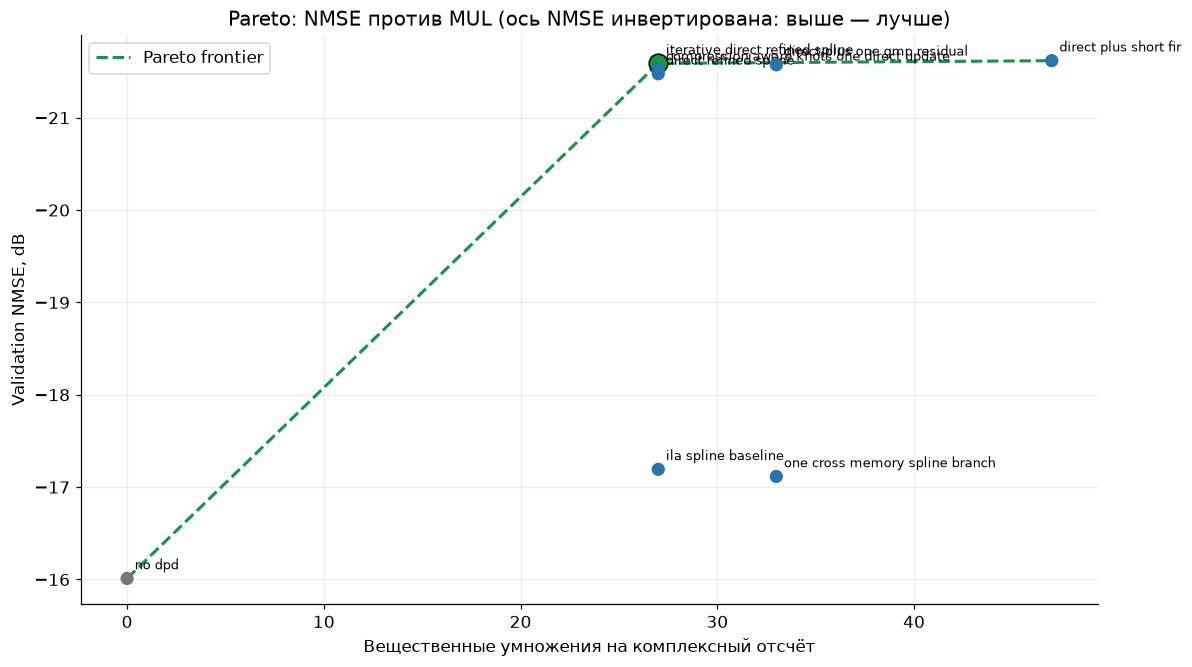

| Fast-path показатель | Значение |
|---|---|
| MUL / complex sample | 27 |
| ADD / complex sample | 28 |
| Вычисления модуля | 3 |
| LUT reads | 6 |
| Comparisons | 15 |
| State, real values | 4 |
| Stored real coefficients | 144 |

In [12]:
points = pareto["points"]
point_by_name = {point["name"]: point for point in points}
frontier_names = pareto["nmse_mul_add_frontier"]

fig, ax = plt.subplots(figsize=(11, 6.2))
for point in points:
    is_recommended = point["name"] == pareto["recommended_for_next_independent_test"]
    color = "#159447" if is_recommended else ("#777777" if point["name"] == "no_dpd" else "#2774ae")
    ax.scatter(
        point["real_multiplications"], point["nmse_db"],
        s=150 if is_recommended else 75, c=color, zorder=3,
        edgecolor="black" if is_recommended else "none",
    )
    ax.annotate(
        point["name"].replace("_", " "),
        (point["real_multiplications"], point["nmse_db"]),
        xytext=(5, 6), textcoords="offset points", fontsize=8.5,
    )

frontier_points = [point_by_name[name] for name in frontier_names]
ax.plot(
    [point["real_multiplications"] for point in frontier_points],
    [point["nmse_db"] for point in frontier_points],
    color="#159447", lw=2, linestyle="--", label="Pareto frontier",
)
ax.set_xlabel("Вещественные умножения на комплексный отсчёт")
ax.set_ylabel("Validation NMSE, dB")
ax.set_title("Pareto: NMSE против MUL (ось NMSE инвертирована: выше — лучше)")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

recommended = point_by_name[pareto["recommended_for_next_independent_test"]]
markdown_table(
    ["Fast-path показатель", "Значение"],
    [
        ["MUL / complex sample", operations["real_multiplications"]],
        ["ADD / complex sample", operations["real_additions"]],
        ["Вычисления модуля", operations["nonlinear_operations"]],
        ["LUT reads", operations["lookups"]],
        ["Comparisons", operations["comparisons"]],
        ["State, real values", operations["state_real_values"]],
        ["Stored real coefficients", operations["stored_real_coefficients"]],
    ],
)

## 12. Проверка ранжирования на альтернативном PA evaluator

Дополнительный GMP evaluator имеет другую выбранную topology и заново обученные коэффициенты, но использует тот же измеренный capture и то же семейство моделей. Поэтому это только слабая robustness-проверка, а не независимое физическое доказательство. Сравнивается устойчивость **порядка моделей**, а не абсолютные NMSE разных evaluator.

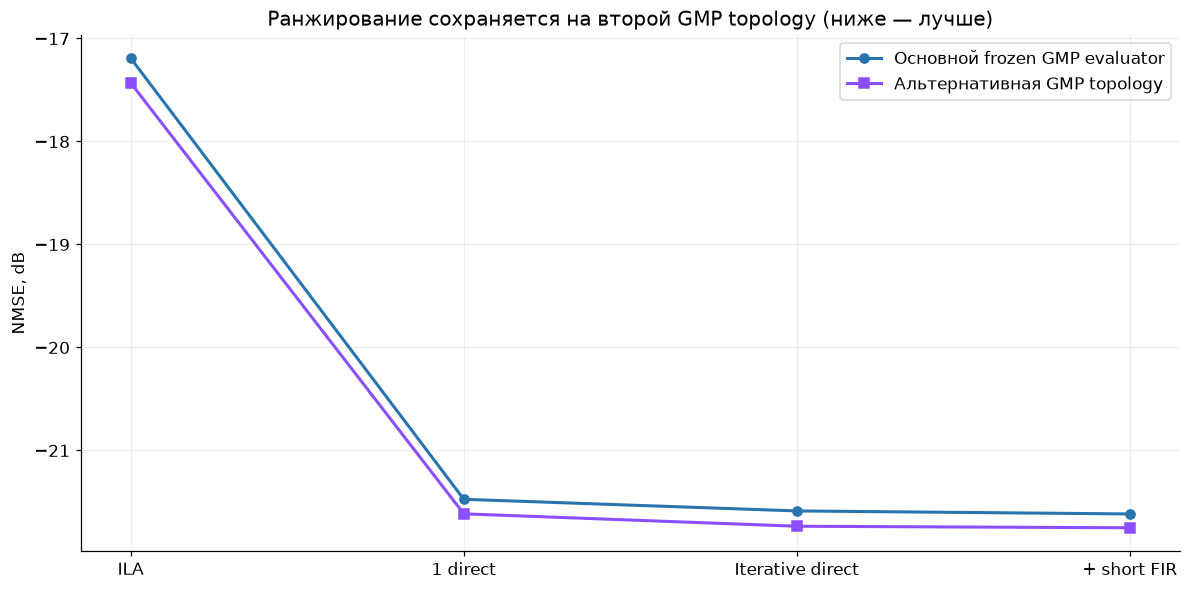

| Модель | Основной evaluator, dB | Альтернативный evaluator, dB |
|---|---|---|
| ILA | -17.192240 | -17.432636 |
| 1 direct | -21.474655 | -21.615802 |
| Iterative direct | -21.587580 | -21.736146 |
| + short FIR | -21.616916 | -21.751300 |

Evidence level: weak independent-topology robustness check
Ограничение: the alternative evaluator uses the same measured capture and the same GMP model family; agreement cannot replace an independently trained neural evaluator or a physical PA test


In [13]:
alternative = artifacts["alternative"]
main_names = [
    "ila_spline_baseline",
    "direct_refined_spline",
    "iterative_direct_refined_spline",
    "direct_plus_short_fir",
]
alternative_alias = {
    "ila_spline_baseline": "ila_spline_baseline",
    "direct_refined_spline": "one_direct_update",
    "iterative_direct_refined_spline": "iterative_direct_refined_spline",
    "direct_plus_short_fir": "direct_plus_short_fir",
}
alternative_by_name = {row["name"]: row for row in alternative["ranking"]}
main_values = [point_by_name[name]["nmse_db"] for name in main_names]
alternative_values = [alternative_by_name[alternative_alias[name]]["nmse_db"] for name in main_names]

xpos = np.arange(len(main_names))
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(xpos, main_values, marker="o", lw=2, label="Основной frozen GMP evaluator", color="#2774ae")
ax.plot(xpos, alternative_values, marker="s", lw=2, label="Альтернативная GMP topology", color="#8a4fff")
ax.set_xticks(xpos, ["ILA", "1 direct", "Iterative direct", "+ short FIR"])
ax.set_ylabel("NMSE, dB")
ax.set_title("Ранжирование сохраняется на второй GMP topology (ниже — лучше)")
ax.legend()
plt.tight_layout()
plt.show()

markdown_table(
    ["Модель", "Основной evaluator, dB", "Альтернативный evaluator, dB"],
    [[label, f"{main:.6f}", f"{alt:.6f}"] for label, main, alt in zip(
        ["ILA", "1 direct", "Iterative direct", "+ short FIR"], main_values, alternative_values
    )],
)
print("Evidence level:", alternative["evidence_level"])
print("Ограничение:", alternative["claim_limit"])

## 13. Residual analysis: почему не добавлялась сложность вслепую

До расширения структуры изучалась остаточная ошибка исходной DPD. Корреляции указали на короткую память и зависимость ошибки от амплитуды, но raw correlation не учитывает локальную чувствительность PA. Это подтвердил отрицательный cross-memory эксперимент: самый высокий residual-score не дал улучшения каскада.

In [14]:
residual = artifacts["residual"]
lag_rows = sorted(residual["lagged_complex_correlations"], key=lambda row: row["complex_correlation"], reverse=True)[:5]
branch_rows = residual["top_cross_memory_branch_scores"][:5]

markdown_table(
    ["Lag", "|complex correlation|"],
    [[row["delay"], f"{row['complex_correlation']:.6f}"] for row in lag_rows],
)
markdown_table(
    ["Signal delay", "Envelope delay", "Train residual score, dB"],
    [[row["signal_delay"], row["envelope_delay"], f"{row['train_inverse_residual_improvement_db']:.6f}"] for row in branch_rows],
)
print("Corr(error power, amplitude):", residual["amplitude_diagnostics"]["corr_error_power_vs_amplitude"])
print("Corr(error power, power):", residual["amplitude_diagnostics"]["corr_error_power_vs_power"])
print("Вывод: raw residual ranking — диагностический сигнал, но не критерий включения ветви.")

| Lag | \|complex correlation\| |
|---|---|
| 4 | 0.111814 |
| 5 | 0.100978 |
| 0 | 0.089593 |
| 3 | 0.075328 |
| 6 | 0.058262 |

| Signal delay | Envelope delay | Train residual score, dB |
|---|---|---|
| 0 | 1 | 0.847538 |
| 5 | 0 | 0.352047 |
| 1 | 0 | 0.340533 |
| 3 | 1 | 0.283978 |
| 0 | 2 | 0.270034 |

Corr(error power, amplitude): 0.19225110817114707
Corr(error power, power): 0.18594430881004015
Вывод: raw residual ranking — диагностический сигнал, но не критерий включения ветви.


## 14. One-shot untouched test waveform

До доступа к test waveform были зафиксированы candidate, hashes, метрика, warm-up, число сегментов и acceptance gate. В one-shot процедуре открыт только желаемый $x_{test}$; измеренный $y_{test}$ не открывался. Путь проверки:

$$
x_{test}\rightarrow\{\text{no DPD},\ \text{ILA},\ \text{iterative direct}\}
\rightarrow\widehat P\rightarrow\widehat y,
$$

где $\widehat P$ — тот же frozen PA surrogate. Поэтому результат проверяет перенос на untouched waveform, но не независимость от ошибок evaluator.

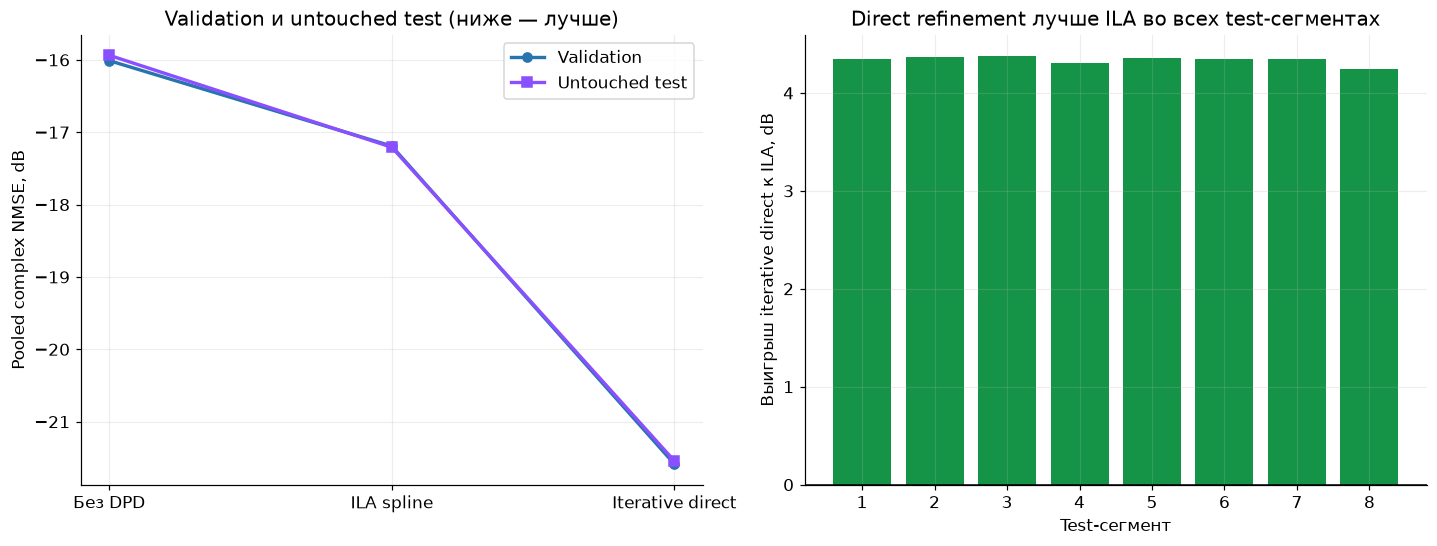

| Режим | Validation NMSE, dB | Untouched test NMSE, dB |
|---|---|---|
| Без DPD | -16.010351 | -15.936111 |
| ILA spline | -17.192240 | -17.207711 |
| Iterative direct | -21.587580 | -21.544509 |

Test gain over ILA: 4.336798 dB
Test gain over no DPD: 5.608398 dB
Минимальный segment gain over ILA: 4.243725 dB
Acceptance pass: True
Test output opened: False
Test input access count: 1
Preregistration SHA-256: bb6286eaa5d91981ea0f0b8b7aebb2583176930de2d62510c8e7a9e8056a2fa8
Claim limit: untouched waveform evidence through the frozen software PA; not measured predistorted output from a physical PA


In [15]:
preregistration = artifacts["preregistration"]
test_metrics = sealed_test["metrics"]
test_no_dpd = test_metrics["no_dpd"]["pooled_complex_nmse_db"]
test_ila = test_metrics["ila_spline"]["pooled_complex_nmse_db"]
test_iterative = test_metrics["iterative_direct_spline"]["pooled_complex_nmse_db"]

comparison_labels = ["Без DPD", "ILA spline", "Iterative direct"]
validation_values = [no_dpd_nmse, ila_nmse, iterative_nmse]
test_values = [test_no_dpd, test_ila, test_iterative]
xpos = np.arange(len(comparison_labels))

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.1))
axes[0].plot(xpos, validation_values, marker="o", lw=2.2, label="Validation", color="#2774ae")
axes[0].plot(xpos, test_values, marker="s", lw=2.2, label="Untouched test", color="#8a4fff")
axes[0].set_xticks(xpos, comparison_labels)
axes[0].set_ylabel("Pooled complex NMSE, dB")
axes[0].set_title("Validation и untouched test (ниже — лучше)")
axes[0].legend()

test_segment_gains = np.asarray(sealed_test["derived"]["segment_gains_over_ila_db"])
axes[1].bar(np.arange(1, len(test_segment_gains) + 1), test_segment_gains, color="#159447")
axes[1].axhline(0.0, color="black", lw=1)
axes[1].set_xlabel("Test-сегмент")
axes[1].set_ylabel("Выигрыш iterative direct к ILA, dB")
axes[1].set_title("Direct refinement лучше ILA во всех test-сегментах")
plt.tight_layout()
plt.show()

markdown_table(
    ["Режим", "Validation NMSE, dB", "Untouched test NMSE, dB"],
    [[name, f"{validation:.6f}", f"{test:.6f}"] for name, validation, test in zip(
        comparison_labels, validation_values, test_values
    )],
)
print(f"Test gain over ILA: {sealed_test['derived']['gain_over_ila_db']:.6f} dB")
print(f"Test gain over no DPD: {sealed_test['derived']['gain_over_no_dpd_db']:.6f} dB")
print(f"Минимальный segment gain over ILA: {test_segment_gains.min():.6f} dB")
print("Acceptance pass:", sealed_test["acceptance_pass"])
print("Test output opened:", sealed_test["test_output_opened"])
print("Test input access count:", sealed_test["test_input_access_count"])
print("Preregistration SHA-256:", sealed_test["preregistration"]["sha256"])
print("Claim limit:", sealed_test["claims_limit"])

## 15. Bit-accurate fixed-point для refined-банка

Числовые форматы и масштабы зафиксированы по train. Проверены 16/14/12-bit входы и коэффициенты, целочисленная интерполяция, широкие аккумуляторы, streaming chunk equivalence, насыщения и столкновения кодов узлов. PA evaluator после целочисленного DPD остаётся float, поэтому это программная fixed-point проверка fast path, а не RTL/HLS timing.

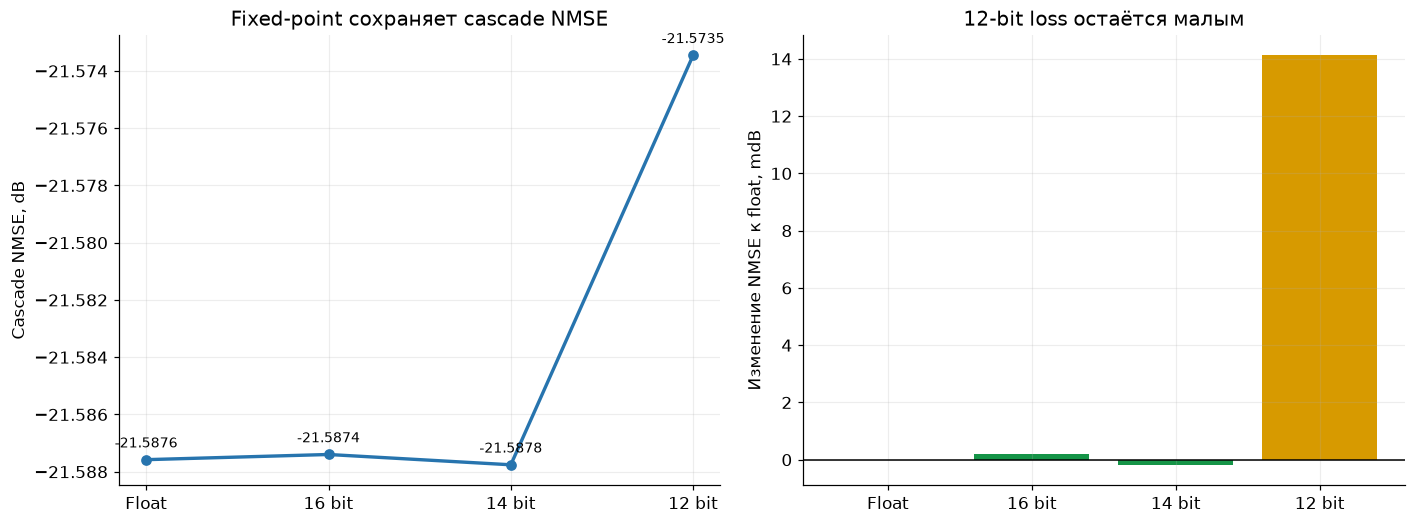

| Bits | Cascade NMSE, dB | Δ к float, dB | Saturations | Knot collisions | Streaming exact |
|---|---|---|---|---|---|
| 16 | -21.587399 | +0.000181 | 0 | 0 | True |
| 14 | -21.587759 | -0.000179 | 0 | 0 | True |
| 12 | -21.573455 | +0.014126 | 0 | 0 | True |

All streaming checks passed: True
Claim limit: bit-accurate Python integer reference through a float PA surrogate; not RTL/HLS timing or a physical-PA result


In [16]:
fixed_formats = fixed_point["formats"]
fixed_labels = ["Float"] + [f"{row['bits']} bit" for row in fixed_formats]
fixed_nmse = [fixed_point["float_reference"]["cascade_nmse_db"]] + [row["cascade_nmse_db"] for row in fixed_formats]
fixed_degradation = [0.0] + [row["cascade_degradation_vs_float_db"] for row in fixed_formats]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.9))
axes[0].plot(np.arange(len(fixed_labels)), fixed_nmse, marker="o", lw=2.2, color="#2774ae")
axes[0].set_xticks(np.arange(len(fixed_labels)), fixed_labels)
axes[0].set_ylabel("Cascade NMSE, dB")
axes[0].set_title("Fixed-point сохраняет cascade NMSE")
for index, value in enumerate(fixed_nmse):
    axes[0].annotate(f"{value:.4f}", (index, value), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=9)

axes[1].bar(np.arange(len(fixed_labels)), np.asarray(fixed_degradation) * 1000.0, color=["#777777", "#159447", "#159447", "#d79a00"])
axes[1].axhline(0.0, color="black", lw=1)
axes[1].set_xticks(np.arange(len(fixed_labels)), fixed_labels)
axes[1].set_ylabel("Изменение NMSE к float, mdB")
axes[1].set_title("12-bit loss остаётся малым")
plt.tight_layout()
plt.show()

fixed_rows = []
for row in fixed_formats:
    stats = row["stats"]
    saturation_count = sum(
        value for key, value in stats.items()
        if key.endswith("_saturations")
    )
    fixed_rows.append([
        row["bits"],
        f"{row['cascade_nmse_db']:.6f}",
        f"{row['cascade_degradation_vs_float_db']:+.6f}",
        saturation_count,
        row["knot_code_collision_count"],
        row["streaming_chunk_equivalence"],
    ])
markdown_table(
    ["Bits", "Cascade NMSE, dB", "Δ к float, dB", "Saturations", "Knot collisions", "Streaming exact"],
    fixed_rows,
)
print("All streaming checks passed:", fixed_point["all_streaming_checks_passed"])
print("Claim limit:", fixed_point["claim_limit"])

## 16. Проверки согласованности отчёта

Ячейка ниже отклоняет несогласованный набор артефактов: разные NMSE для одной модели, изменение operation count или неправильную рекомендацию Pareto.

In [17]:
assert direct["operation_count_changed"] is False
assert iterative["operation_count_changed"] is False
assert direct["operation_count"] == iterative["operation_count"]
assert np.isclose(one_update_nmse, iterative["one_update_validation"]["nmse_db"], atol=1e-12)
assert np.isclose(
    iterative_nmse,
    point_by_name["iterative_direct_refined_spline"]["nmse_db"],
    atol=1e-12,
)
assert pareto["recommended_for_next_independent_test"] == "iterative_direct_refined_spline"
assert all(
    point_by_name[name]["status"] != "recommended_fast_path"
    for name in point_by_name
    if name != "iterative_direct_refined_spline"
)
assert artifacts["robustness"]["all_cases_improve_every_validation_segment"] is True
assert alternative["ranking_names_best_first"].index("iterative_direct_refined_spline") < alternative["ranking_names_best_first"].index("ila_spline_baseline")
assert preregistration["status"] == "frozen_before_test_access"
assert preregistration["rerun_or_retuning_after_test"] is False
assert sealed_test["test_output_opened"] is False
assert sealed_test["test_input_access_count"] == 1
assert sealed_test["acceptance_pass"] is True
assert all(sealed_test["acceptance_checks"].values())
assert fixed_point["validation_used_for_numeric_scale_or_precision_selection"] is False
assert fixed_point["all_streaming_checks_passed"] is True
for row in fixed_formats:
    assert row["streaming_chunk_equivalence"] is True
    assert row["knot_code_collision_count"] == 0
    assert row["coefficient_saturation_count"] == 0
    assert all(
        value == 0 for key, value in row["stats"].items()
        if key.endswith("_saturations")
    )

print("Согласованность обязательных результатов: PASS")
print("Топология baseline/refined совпадает: PASS")
print("Operation count не изменился: PASS")
print("Все robustness cases улучшают каждый validation-сегмент: PASS")
print("One-shot test acceptance и отсутствие test-output access: PASS")
print("16/14/12-bit streaming, saturation и knot-collision checks: PASS")

Согласованность обязательных результатов: PASS
Топология baseline/refined совпадает: PASS
Operation count не изменился: PASS
Все robustness cases улучшают каждый validation-сегмент: PASS
One-shot test acceptance и отсутствие test-output access: PASS
16/14/12-bit streaming, saturation и knot-collision checks: PASS


## 17. Что доказано и что не доказано

### Подтверждено сохранёнными артефактами

- исходная и refined-модели имеют одинаковую spline-memory topology;
- direct refinement значительно улучшает pooled validation NMSE на основном frozen PA evaluator;
- улучшение наблюдается на каждом из восьми временных сегментов;
- заранее зарегистрированный candidate прошёл one-shot untouched test waveform;
- 16/14/12-bit integer-reference проверка нового банка прошла без насыщений и knot collisions;
- цельная и chunked fixed-point обработка совпадают;
- порядок ILA < direct сохраняется на альтернативной GMP topology;
- inference-cost не изменился;
- tested structural extensions дают отрицательный или слишком малый дополнительный выигрыш.

### Подтверждено только через программную PA-модель

- все cascade NMSE в этом отчёте;
- sealed-test NMSE, поскольку untouched waveform обрабатывался frozen PA surrogate;
- peak/PAPR предыскажённого сигнала относительно поддержки evaluator;
- вывод о преимуществе direct refinement над ILA.

### Пока не подтверждено

- подавление в официально определённых спектральных областях;
- качество на физическом PA;
- RTL/HLS synthesis и hardware timing;
- перенос на независимый capture или другой PA evaluator family;
- превосходство над OpenDPD на одном PA и одном протоколе.

## 18. Итоговое решение

Для следующей физической или действительно независимой проверки выбран **iterative direct-refined spline-memory DPD**. Он даёт лучший подтверждённый Pareto trade-off в текущем BlackBox surrogate experiment: крупный выигрыш по NMSE при той же рабочей архитектуре и той же аналитической стоимости. Результат перенёсся на one-shot untouched waveform и сохранился при 12-bit программной арифметике. Дальнейшее усложнение на том же evaluator приостанавливается, потому что малые surrogate-улучшения уже сопоставимы с риском подгонки под ошибку PA-модели.

## 19. Как воспроизвести экспериментальные артефакты

Из корня репозитория последовательно выполнить:

```bash
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage residual
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage direct
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage direct-robustness
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage cross
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage gmp-residual
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage fir
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage direct-iterative
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage knots
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage alternative-evaluator
python -m experiments.evaluate_blackbox_dpd_hypotheses --stage fixed-point
```

One-shot test уже выполнен согласно preregistration; повторно открывать test waveform для retuning нельзя. Затем выполнить этот notebook сверху вниз. Перезапуск гипотез изменяет артефакты, поэтому перед внешней фиксацией необходимо сохранить их hashes и состояние кода.